# 🇮🇳 Indian Airports: Graph-Ready EDA & DB Preparation
**Objective:** Perform Exploratory Data Analysis (EDA) to ensure the raw CSV data is mathematically sound and structurally ready for a PostgreSQL Graph Schema (Nodes and Edges optimized for Dijkstra's Algorithm).

**Key Graph Requirements:**
1. **Nodes ($V$)**: Must have unique, non-null identifiers (Primary Keys).
2. **Coordinates ($X, Y$)**: Must be strictly bounded within India's geographical limits.
3. **Connectivity**: Exclude 'closed' airports or irrelevant nodes (e.g., balloon ports) that cannot participate in fixed-wing routing.



### **Code Cell 1: Setup and Library Imports**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plotting style for academic/thesis readiness
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries successfully imported. Ready for EDA.")

Libraries successfully imported. Ready for EDA.


### **Code Cell 2: Phase 1 - Loading & Structural Overview**

In [2]:
# Load directly from URL to keep local disk clean
url = "https://ourairports.com/countries/IN/airports.csv"
print(f"Fetching data from: {url}...\n")
df = pd.read_csv(url)

# 1. Basic Metadata
print(f"Dataset Shape (Rows, Columns): {df.shape}")
print("-" * 50)
print("Data Types & Non-Null Counts:")
df.info()

# 2. Preview the first 3 rows to inspect the raw structure
display(df.head(3))


Fetching data from: https://ourairports.com/countries/IN/airports.csv...

Dataset Shape (Rows, Columns): (649, 24)
--------------------------------------------------
Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 649 non-null    int64  
 1   ident              649 non-null    object 
 2   type               649 non-null    object 
 3   name               649 non-null    object 
 4   latitude_deg       649 non-null    float64
 5   longitude_deg      649 non-null    float64
 6   elevation_ft       404 non-null    float64
 7   continent          649 non-null    object 
 8   country_name       649 non-null    object 
 9   iso_country        649 non-null    object 
 10  region_name        649 non-null    object 
 11  iso_region         649 non-null    object 
 12  local_region       649

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,26555,VIDP,large_airport,Indira Gandhi International Airport,28.555630,77.095190,777.0,AS,India,IN,...,1,VIDP,VIDP,DEL,NaN,https://www.newdelhiairport.in/,https://en.wikipedia.org/wiki/Indira_Gandhi_In...,Palam Air Force Station,51475,2026-04-05T17:34:25+00:00
1,26434,VABB,large_airport,Chhatrapati Shivaji Maharaj International Airport,19.088699,72.867897,39.0,AS,India,IN,...,1,VABB,VABB,BOM,NaN,http://www.csia.in/,https://en.wikipedia.org/wiki/Chhatrapati_Shiv...,"Bombay, Sahar International Airport",1014475,2026-01-12T21:21:50+00:00
2,26618,VOMM,large_airport,Chennai International Airport,12.990005,80.169296,52.0,AS,India,IN,...,1,VOMM,VOMM,MAA,NaN,NaN,https://en.wikipedia.org/wiki/Chennai_Internat...,Madras,51150,2022-09-09T12:28:58+00:00


### **Phase 2 - Mathematical & Spatial EDA (Plotting)**
Before we load nodes into the database, we must visualize the data. If the coordinates are wrong, the Haversine edge weights will be corrupted, breaking the Dijkstra implementation.

### **Code Cell 3: Visualizing Node Distribution (Airport Types)**

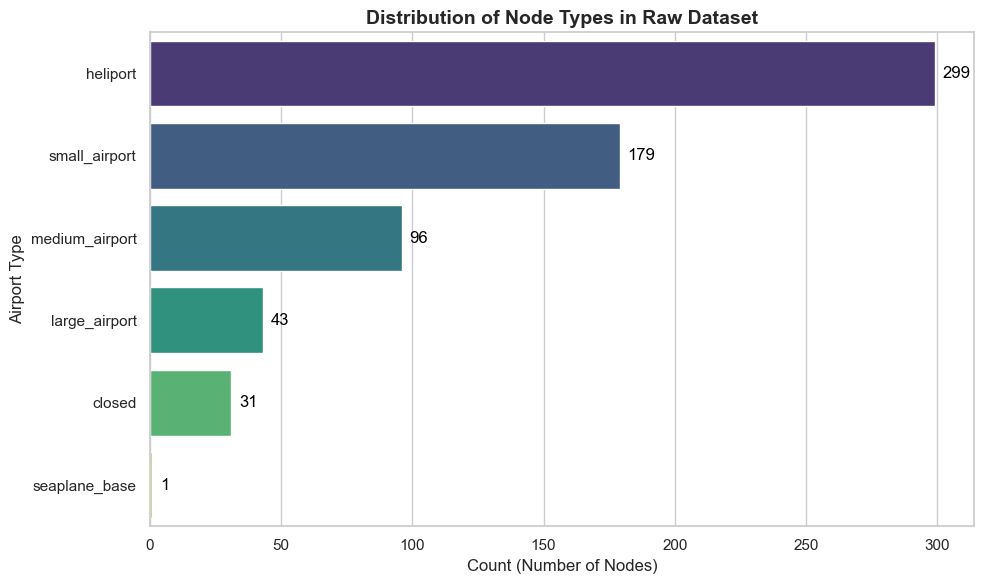

Observation: Notice the high number of 'heliport' and 'closed' types. These will likely need pruning for a mainline graph.


In [3]:
# Plotting the distribution of Airport Types
plt.figure(figsize=(10, 6))
type_counts = df['type'].value_counts()
ax = sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index, dodge=False, palette="viridis", legend=False)

plt.title("Distribution of Node Types in Raw Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Count (Number of Nodes)", fontsize=12)
plt.ylabel("Airport Type", fontsize=12)

# Add exact numbers to the bars
for i, v in enumerate(type_counts.values):
    ax.text(v + 3, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

print("Observation: Notice the high number of 'heliport' and 'closed' types. These will likely need pruning for a mainline graph.")

### **Code Cell 4: Geospatial Sanity Check (Mathematical Bounds)**
*India's approximate bounding box: Latitudes [8.0, 37.5] and Longitudes [68.0, 97.5]. Let's plot our coordinates to see if they form the shape of India or if there are outliers (data entry errors).*


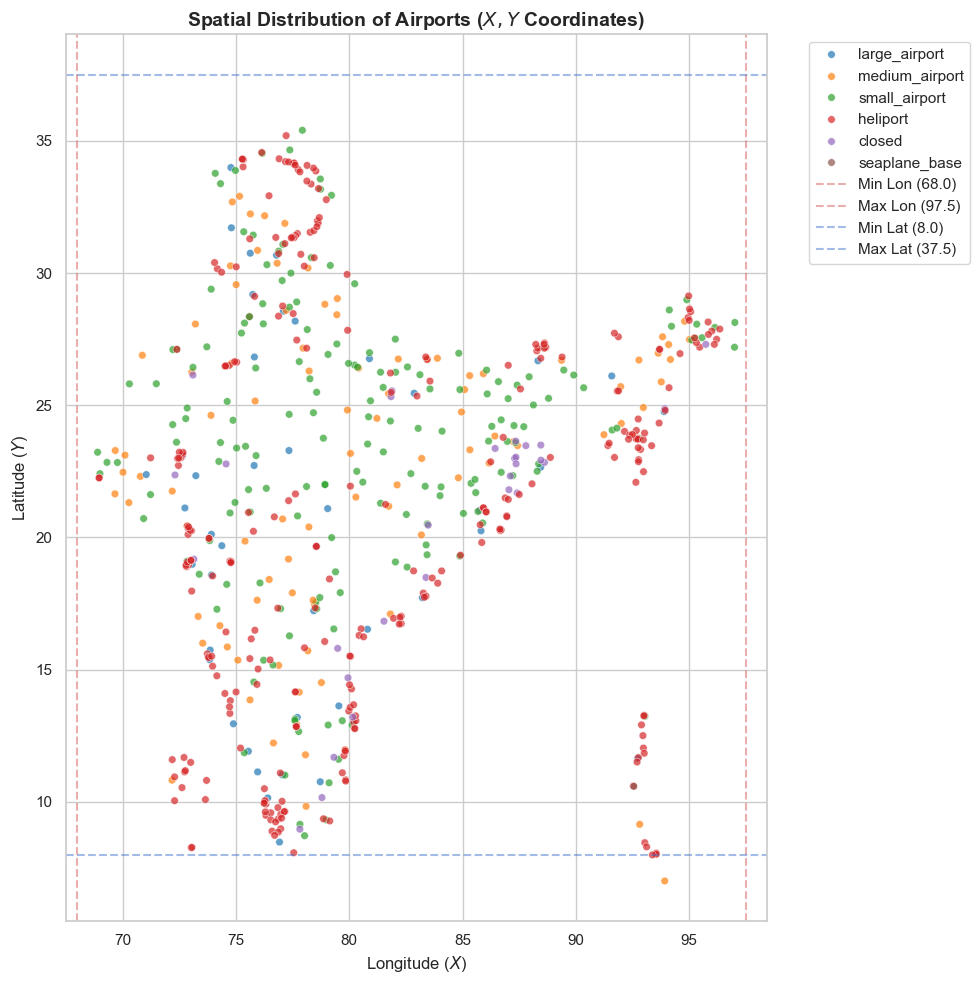

Found 2 spatial anomalies (nodes outside standard India bounds).


,ident,name,type,latitude_deg,longitude_deg
203,VO94,Campbell Bay Airport / INS Baaz,medium_airport,7.01304,93.922798
547,IN-0299,Katchal Heliport,heliport,7.99756,93.379380


In [4]:
plt.figure(figsize=(10, 10))

# Scatter plot of Longitude (X) vs Latitude (Y)
sns.scatterplot(
    data=df, 
    x='longitude_deg', 
    y='latitude_deg', 
    hue='type',
    palette='tab10',
    s=30, 
    alpha=0.7
)

# Overlay India's mathematical bounding box
plt.axvline(x=68.0, color='r', linestyle='--', alpha=0.5, label='Min Lon (68.0)')
plt.axvline(x=97.5, color='r', linestyle='--', alpha=0.5, label='Max Lon (97.5)')
plt.axhline(y=8.0, color='b', linestyle='--', alpha=0.5, label='Min Lat (8.0)')
plt.axhline(y=37.5, color='b', linestyle='--', alpha=0.5, label='Max Lat (37.5)')

plt.title("Spatial Distribution of Airports ($X, Y$ Coordinates)", fontsize=14, fontweight='bold')
plt.xlabel("Longitude ($X$)", fontsize=12)
plt.ylabel("Latitude ($Y$)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Detect spatial anomalies
anomalies = df[
    (df['longitude_deg'] < 68.0) | (df['longitude_deg'] > 97.5) | 
    (df['latitude_deg'] < 8.0) | (df['latitude_deg'] > 37.5)
]
print(f"Found {len(anomalies)} spatial anomalies (nodes outside standard India bounds).")
if len(anomalies) > 0:
    display(anomalies[['ident', 'name', 'type', 'latitude_deg', 'longitude_deg']])

### **Phase 3 - DB Readiness & Constraint Validation**
To load this into PostgreSQL without "violating non-null constraint" errors, we must assert that our Primary Keys and Coordinate columns are strictly valid. We will also clean the data by dropping closed airports.


### **Code Cell 5: Primary Key & DB Constraint Checks**


In [5]:
# 1. Primary Key Uniqueness Check (ident)
is_pk_unique = df['ident'].is_unique
print(f"[DB Check] Is 'ident' column strictly unique? : {is_pk_unique}")
if not is_pk_unique:
    print("WARNING: Duplicate 'ident' keys found. Database INSERT will fail.")

# 2. Null Checks for Required Fields
critical_cols = ['ident', 'name', 'latitude_deg', 'longitude_deg', 'iso_region']
null_counts = df[critical_cols].isnull().sum()

print("\n[DB Check] Null values in critical columns:")
print(null_counts)

if null_counts.sum() == 0:
    print("SUCCESS: All nodes have valid PKs and Coordinates. Mathematical layer is safe.")
else:
    print("WARNING: Nulls detected in critical columns. Must drop or impute before DB insertion.")


[DB Check] Is 'ident' column strictly unique? : True

[DB Check] Null values in critical columns:
ident            0
name             0
latitude_deg     0
longitude_deg    0
iso_region       0
dtype: int64
SUCCESS: All nodes have valid PKs and Coordinates. Mathematical layer is safe.



### **Code Cell 6: Building the "Mainline Graph" (Data Pruning)**


In [6]:

# Creating a clean DataFrame for the DB
db_airports = df.copy()

# Filter 1: Remove 'closed' airports (they cannot be traversed)
db_airports = db_airports[db_airports['type'] != 'closed']

# Filter 2: (Optional) Remove heliports if your graph is fixed-wing flight only
db_airports = db_airports[db_airports['type'] != 'heliport']

# Filter 3: Select only the columns defined in our Postgres Schema
schema_columns = ['ident', 'name', 'latitude_deg', 'longitude_deg', 'iso_region', 'type']
db_airports = db_airports[schema_columns]

print(f"Original Node Count: {len(df)}")
print(f"Cleaned Graph Node Count: {len(db_airports)}")
print(f"Nodes Pruned: {len(df) - len(db_airports)}")

display(db_airports.head())

Original Node Count: 649
Cleaned Graph Node Count: 319
Nodes Pruned: 330


,ident,name,latitude_deg,longitude_deg,iso_region,type
0,VIDP,Indira Gandhi International Airport,28.555630,77.095190,IN-DL,large_airport
1,VABB,Chhatrapati Shivaji Maharaj International Airport,19.088699,72.867897,IN-MM,large_airport
2,VOMM,Chennai International Airport,12.990005,80.169296,IN-TN,large_airport
3,VOBL,Kempegowda International Airport Bengaluru,13.197900,77.706299,IN-KA,large_airport
4,VOHS,Rajiv Gandhi International Airport,17.231318,78.429855,IN-TG,large_airport



### **Code Cell 7: Export to Database-Ready CSV**


In [7]:
# Export to a local CSV so it can be ingested via PostgreSQL's \copy command
export_path = "india_graph_nodes_clean.csv"
db_airports.to_csv(export_path, index=False)
print(f"Successfully exported clean nodes to {export_path}")
print("Ready for PostgreSQL ingestion!")

Successfully exported clean nodes to india_graph_nodes_clean.csv
Ready for PostgreSQL ingestion!
